# Tech Challenge Fase 2 — Otimização de Modelo de Detecção de Sepse

Este notebook apresenta os resultados finais da Fase 2 do Tech Challenge de forma visual e didática. Ele não treina modelos, não executa o Algoritmo Genético e não realiza chamadas externas. Todos os dados exibidos são carregados diretamente dos arquivos disponíveis em `reports/`.

## 1. Introdução.

Na Fase 1, foi desenvolvido um modelo de Machine Learning para apoiar a triagem de risco de sepse. Nesta Fase 2, o objetivo foi evoluir esse modelo por meio de Algoritmo Genético, otimizando os hiperparâmetros do XGBoost e adicionando uma camada de explicabilidade em linguagem natural com LLM ou fallback local.

Em um contexto de triagem de sepse, o falso negativo é o erro mais crítico, pois representa um paciente com risco real que não foi sinalizado pelo modelo. Por isso, este projeto prioriza o aumento do recall e a redução dos falsos negativos.

## 2. Configuração inicial.

A célula abaixo importa apenas bibliotecas de análise e visualização. O notebook utiliza `pandas` para organizar tabelas e `matplotlib` para gerar gráficos simples e adequados para apresentação.

In [1]:
import ast
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE_DIR = Path("..")
if not (BASE_DIR / "reports").exists():
    BASE_DIR = Path(".")
REPORTS_DIR = BASE_DIR / "reports"


def read_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def format_percent(value: float) -> str:
    return f"{value:.3f}"


def format_large_number(value) -> str:
    try:
        return f"{int(value):,}".replace(",", ".")
    except Exception:
        return str(value)


def bool_value(value) -> bool:
    if isinstance(value, str):
        return value.strip().lower() == "true"
    return bool(value)


def metric_table(metrics: dict) -> pd.DataFrame:
    keys = [
        "accuracy", "recall", "precision", "f1_score",
        "false_negatives", "false_positives", "true_positives", "true_negatives",
    ]
    rows = [{"métrica": key, "valor": metrics.get(key, "não disponível")} for key in keys]
    return pd.DataFrame(rows)


def plot_bar_comparison(data, x_col, y_col, title, xlabel, ylabel, value_formatter=None):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(data[x_col], data[y_col])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        label = value_formatter(height) if value_formatter else f"{height:.3f}"
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label,
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()


def friendly_model_name(name: str) -> str:
    mapping = {
        "baseline_original": "Modelo original",
        "modelo_otimizado_ga": "Modelo otimizado",
    }
    return mapping.get(name, name)


def parse_hyperparameters(value):
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            return {"valor_original": value}
    return {}

print(f"Diretório de relatórios: {REPORTS_DIR.resolve()}")

Diretório de relatórios: C:\Users\Mathe\OneDrive\Área de Trabalho\projects\projeto_sepse_2.0\reports


## 3. Carregamento dos resultados.

Nesta etapa, o notebook carrega os arquivos finais da pasta `reports/`. Se algum resultado estiver marcado como `quick=True`, o notebook exibe um aviso para evitar que uma execução rápida seja interpretada como resultado final.

In [2]:
baseline_metrics = read_json(REPORTS_DIR / "baseline_metrics.json")
optimized_metrics = read_json(REPORTS_DIR / "optimized_metrics.json")
ga_experiments = pd.read_csv(REPORTS_DIR / "ga_experiments_summary.csv")
llm_examples = read_json(REPORTS_DIR / "llm_explanation_examples.json")

predict_example_path = REPORTS_DIR / "predict_and_explain_example.json"
predict_example = read_json(predict_example_path) if predict_example_path.exists() else None

threshold_tuning_path = REPORTS_DIR / "threshold_tuning.csv"
threshold_tuning = pd.read_csv(threshold_tuning_path) if threshold_tuning_path.exists() else None

quick_ga = ga_experiments["quick"].apply(bool_value).any() if "quick" in ga_experiments.columns else False
quick_optimized = bool_value(optimized_metrics.get("quick", False))

if quick_ga or quick_optimized:
    display(Markdown("**Aviso:** há resultados marcados como `quick=True`. Eles servem apenas para validação técnica."))
else:
    display(Markdown("**Resultados finais carregados com `quick=False`.**"))

**Resultados finais carregados com `quick=False`.**

## 4. Baseline: modelo original.

O baseline representa o modelo original da Fase 1. Ele serve como ponto de comparação para avaliar se a otimização realizada na Fase 2 trouxe melhorias nas métricas clínicas mais importantes.

In [3]:
baseline_table = metric_table(baseline_metrics)
display(baseline_table)

,métrica,valor
0,accuracy,0.650335
1,recall,0.548053
2,precision,0.135436
3,f1_score,0.217198
4,false_negatives,30482.000000
5,false_positives,235961.000000
6,true_positives,36964.000000
7,true_negatives,458588.000000


## 5. Algoritmo Genético.

O Algoritmo Genético foi utilizado para buscar automaticamente melhores combinações de hiperparâmetros do XGBoost. Cada indivíduo representa uma configuração possível do modelo. A cada geração, os melhores indivíduos são selecionados, combinados por crossover e modificados por mutação.

Os genes avaliados foram: `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha` e `reg_lambda`.

O processo incluiu população inicial, seleção por torneio, crossover, mutação, elitismo e avaliação por fitness.

In [4]:
ga_columns = [
    "experiment", "population_size", "generations", "mutation_rate", "quick",
    "best_fitness", "accuracy", "recall", "precision", "f1_score",
    "false_negatives", "false_positives", "threshold",
]
ga_view = ga_experiments[[col for col in ga_columns if col in ga_experiments.columns]].copy()
display(ga_view)

best_experiment = ga_experiments.sort_values("best_fitness", ascending=False).iloc[0]
display(Markdown(
    f"**Melhor experimento:** {best_experiment['experiment']}  \n"
    f"**Best fitness:** {best_experiment['best_fitness']:.6f}"
))

,experiment,population_size,generations,mutation_rate,quick,best_fitness,accuracy,recall,precision,f1_score,false_negatives,false_positives,threshold
0,1,10,5,0.1,False,0.635362,0.217606,0.994956,0.145096,0.253259,107,124368,0.12
1,2,20,8,0.2,False,0.635367,0.232622,0.993165,0.147331,0.256598,145,121941,0.12
2,3,30,10,0.3,False,0.635758,0.235168,0.993401,0.147774,0.257277,140,121541,0.12


**Melhor experimento:** 3  
**Best fitness:** 0.635758

## 6. Visualização dos experimentos do Algoritmo Genético.

A fitness é a pontuação usada para comparar os indivíduos do Algoritmo Genético. Neste projeto, ela foi construída para valorizar recall e F1-score, penalizando falsos negativos.

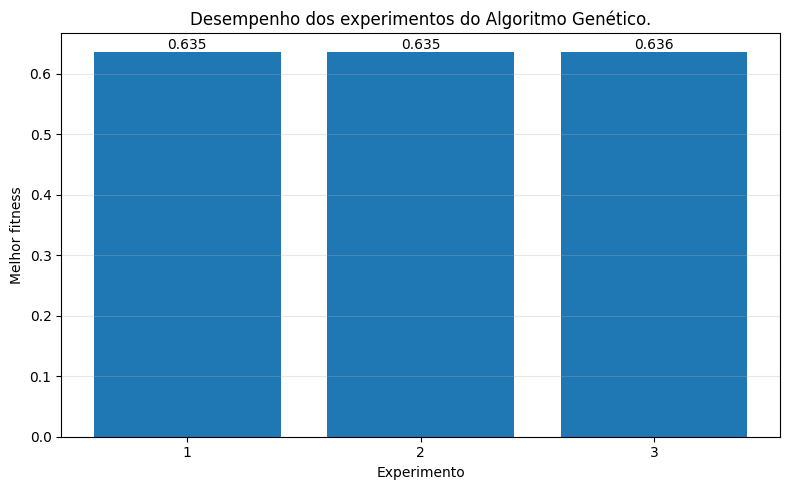

In [5]:
ga_plot = ga_experiments.copy()
ga_plot["Experimento"] = ga_plot["experiment"].astype(str)
plot_bar_comparison(
    ga_plot,
    "Experimento",
    "best_fitness",
    "Desempenho dos experimentos do Algoritmo Genético.",
    "Experimento",
    "Melhor fitness",
    format_percent,
)

O recall mede a capacidade do modelo de identificar casos reais de sepse. Quanto maior o recall, menor a chance de deixar passar pacientes em risco.

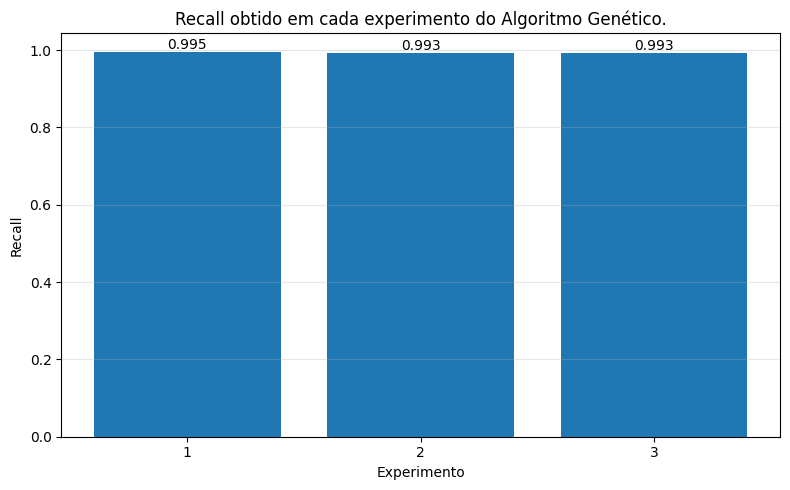

In [6]:
plot_bar_comparison(
    ga_plot,
    "Experimento",
    "recall",
    "Recall obtido em cada experimento do Algoritmo Genético.",
    "Experimento",
    "Recall",
    format_percent,
)

Falsos negativos são casos reais de sepse que o modelo classificou como sem risco. Em triagem médica, esse é o erro mais crítico, pois pode atrasar a avaliação clínica.

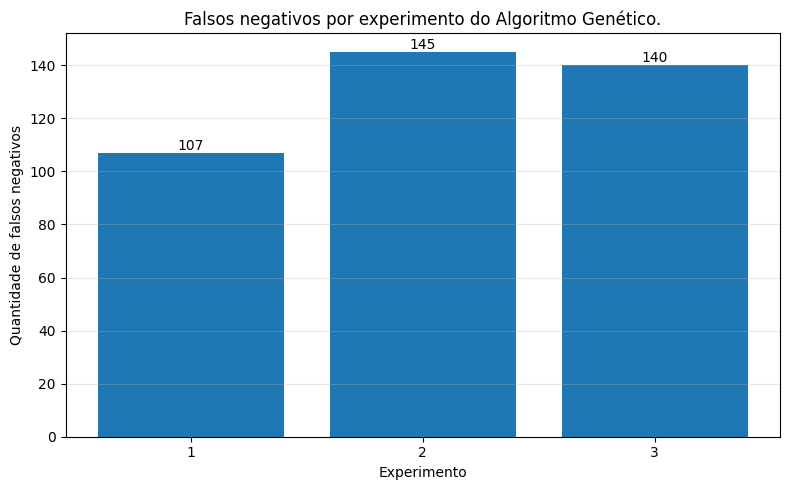

In [7]:
plot_bar_comparison(
    ga_plot,
    "Experimento",
    "false_negatives",
    "Falsos negativos por experimento do Algoritmo Genético.",
    "Experimento",
    "Quantidade de falsos negativos",
    format_large_number,
)

Falsos positivos representam alertas emitidos para casos sem sepse real. O aumento desses alertas é o principal custo do ganho de sensibilidade do modelo otimizado.

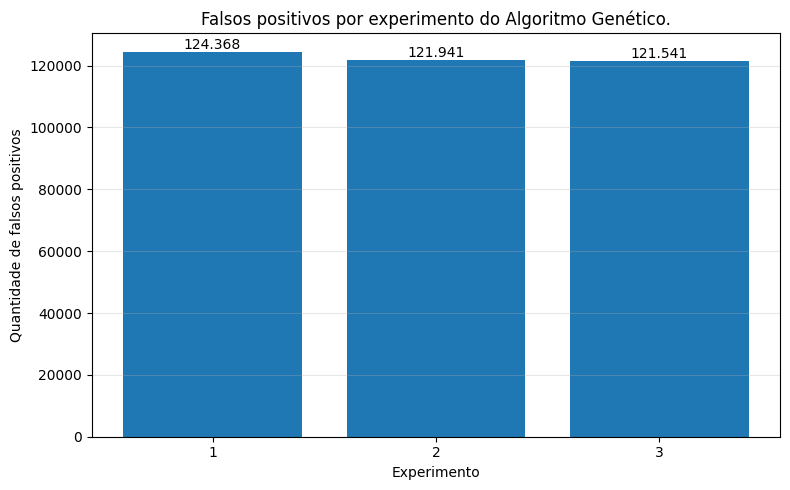

In [8]:
plot_bar_comparison(
    ga_plot,
    "Experimento",
    "false_positives",
    "Falsos positivos por experimento do Algoritmo Genético.",
    "Experimento",
    "Quantidade de falsos positivos",
    format_large_number,
)

## 7. Melhor experimento e hiperparâmetros encontrados.

O melhor experimento foi selecionado com base na maior fitness. A configuração encontrada pelo Algoritmo Genético foi utilizada para treinar o modelo otimizado final.

In [9]:
best_hyperparameters = parse_hyperparameters(best_experiment.get("best_hyperparameters"))
hyperparameters_table = pd.DataFrame(
    [{"hiperparâmetro": key, "valor": value} for key, value in best_hyperparameters.items()]
)

display(Markdown(
    f"**Experimento selecionado:** {best_experiment['experiment']}  \n"
    f"**Fitness:** {best_experiment['best_fitness']:.6f}"
))
display(hyperparameters_table)

**Experimento selecionado:** 3  
**Fitness:** 0.635758

,hiperparâmetro,valor
0,max_depth,6.00000
1,learning_rate,0.03278
2,n_estimators,371.00000
3,subsample,0.69849
4,colsample_bytree,0.82084
5,min_child_weight,3.00000
6,gamma,2.79547
7,reg_alpha,2.19110
8,reg_lambda,3.96307


## 8. Ajuste de threshold.

Após a escolha dos hiperparâmetros pelo Algoritmo Genético, foi realizado o ajuste de threshold usando o conjunto de validação. Essa etapa busca equilibrar recall, F1-score, precision e penalização por falsos negativos. O conjunto de teste foi usado apenas para a avaliação final.

In [10]:
threshold_info = pd.DataFrame([
    {"item": "Threshold original", "valor": optimized_metrics.get("original_threshold", baseline_metrics.get("threshold", "não disponível"))},
    {"item": "Threshold final", "valor": optimized_metrics.get("best_threshold", optimized_metrics.get("threshold", "não disponível"))},
    {"item": "Estratégia", "valor": optimized_metrics.get("threshold_strategy", "não disponível")},
    {"item": "Fonte", "valor": optimized_metrics.get("threshold_source", "não disponível")},
])
display(threshold_info)

,item,valor
0,Threshold original,0.12
1,Threshold final,0.15
2,Estratégia,validation_fitness
3,Fonte,validation_set


O gráfico abaixo mostra como a alteração do threshold impacta o recall. Thresholds menores tendem a aumentar a sensibilidade, mas também podem elevar a quantidade de alertas falsos.

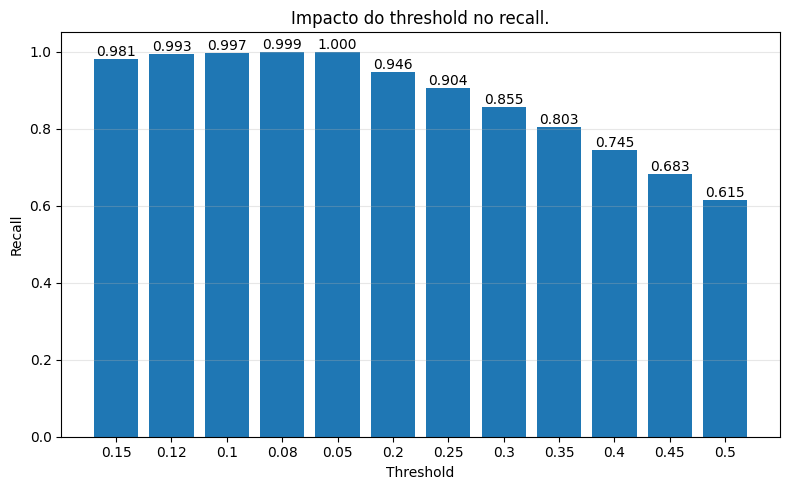

In [11]:
if threshold_tuning is not None:
    threshold_plot = threshold_tuning.copy()
    threshold_plot["Threshold"] = threshold_plot["threshold"].astype(str)
    plot_bar_comparison(
        threshold_plot,
        "Threshold",
        "recall",
        "Impacto do threshold no recall.",
        "Threshold",
        "Recall",
        format_percent,
    )
else:
    display(Markdown("Arquivo `threshold_tuning.csv` não encontrado."))

Este gráfico mostra o impacto do threshold na quantidade de falsos positivos. Essa métrica ajuda a visualizar o custo operacional de tornar o modelo mais sensível.

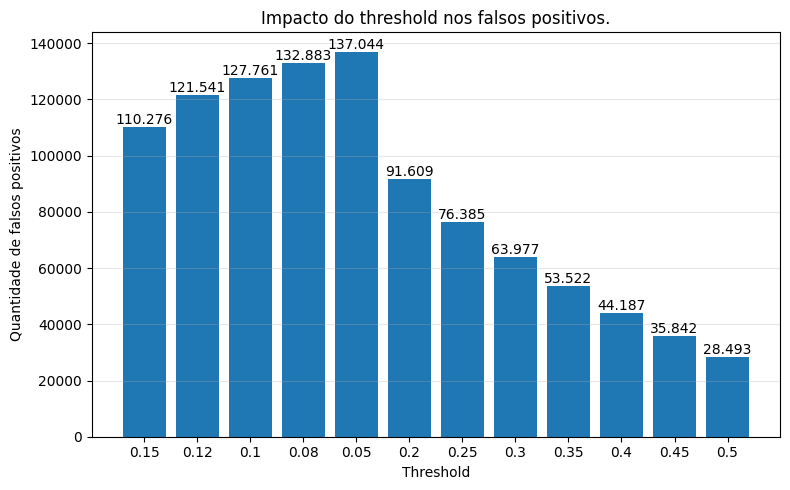

In [12]:
if threshold_tuning is not None:
    plot_bar_comparison(
        threshold_plot,
        "Threshold",
        "false_positives",
        "Impacto do threshold nos falsos positivos.",
        "Threshold",
        "Quantidade de falsos positivos",
        format_large_number,
    )
else:
    display(Markdown("Arquivo `threshold_tuning.csv` não encontrado."))

## 9. Comparação entre o modelo original e o modelo otimizado.

O modelo otimizado reduziu falsos negativos, aumentando a sensibilidade da triagem. Como consequência, houve aumento de falsos positivos e queda de precision/F1-score. Em um contexto de sepse, esse trade-off deve ser analisado com cautela, pois o modelo é uma ferramenta acadêmica de apoio e não substitui avaliação médica.

In [13]:
comparison = pd.DataFrame([
    {"modelo": "Modelo original", **baseline_metrics},
    {"modelo": "Modelo otimizado", **optimized_metrics},
])
comparison_columns = ["modelo", "accuracy", "recall", "precision", "f1_score", "false_negatives", "false_positives"]
comparison_view = comparison[comparison_columns]
display(comparison_view)

deltas = {
    "delta_recall": optimized_metrics["recall"] - baseline_metrics["recall"],
    "delta_precision": optimized_metrics["precision"] - baseline_metrics["precision"],
    "delta_f1_score": optimized_metrics["f1_score"] - baseline_metrics["f1_score"],
    "reducao_false_negatives": baseline_metrics["false_negatives"] - optimized_metrics["false_negatives"],
    "aumento_false_positives": optimized_metrics["false_positives"] - baseline_metrics["false_positives"],
}
display(pd.DataFrame([deltas]))

display(Markdown(
    "**Resultado principal:** o modelo otimizado reduziu os falsos negativos de "
    f"{format_large_number(baseline_metrics['false_negatives'])} para "
    f"{format_large_number(optimized_metrics['false_negatives'])} e aumentou o recall de "
    f"{baseline_metrics['recall']:.3f} para {optimized_metrics['recall']:.3f}. "
    "O custo foi o aumento dos falsos positivos."
))

,modelo,accuracy,recall,precision,f1_score,false_negatives,false_positives
0,Modelo original,0.650335,0.548053,0.135436,0.217198,30482,235961
1,Modelo otimizado,0.240042,0.925170,0.098044,0.177300,5047,574037


,delta_recall,delta_precision,delta_f1_score,reducao_false_negatives,aumento_false_positives
0,0.377117,-0.037392,-0.039899,25435,338076


**Resultado principal:** o modelo otimizado reduziu os falsos negativos de 30.482 para 5.047 e aumentou o recall de 0.548 para 0.925. O custo foi o aumento dos falsos positivos.

## 10. Visualização comparativa: modelo original vs. modelo otimizado.

O recall mede a capacidade do modelo de identificar casos reais de sepse. Quanto maior o recall, menor a chance de deixar passar pacientes em risco.

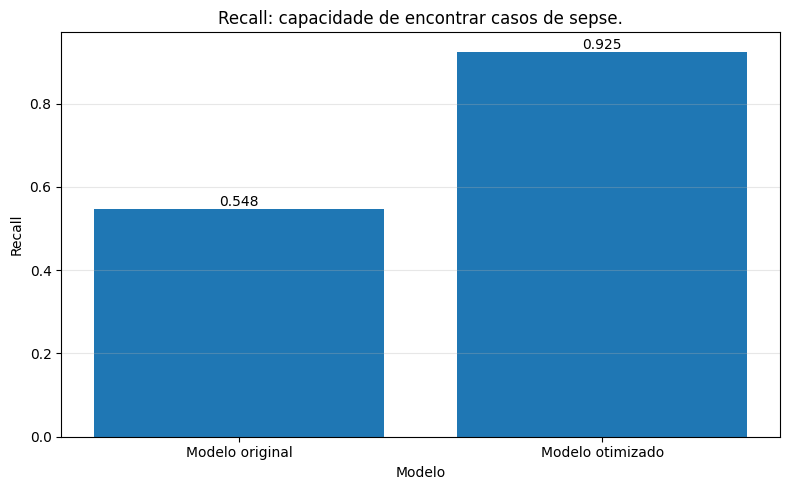

In [14]:
plot_bar_comparison(
    comparison_view,
    "modelo",
    "recall",
    "Recall: capacidade de encontrar casos de sepse.",
    "Modelo",
    "Recall",
    format_percent,
)

Falsos negativos são casos reais de sepse que o modelo classificou como sem risco. Em triagem médica, esse é o erro mais crítico, pois pode atrasar a avaliação clínica.

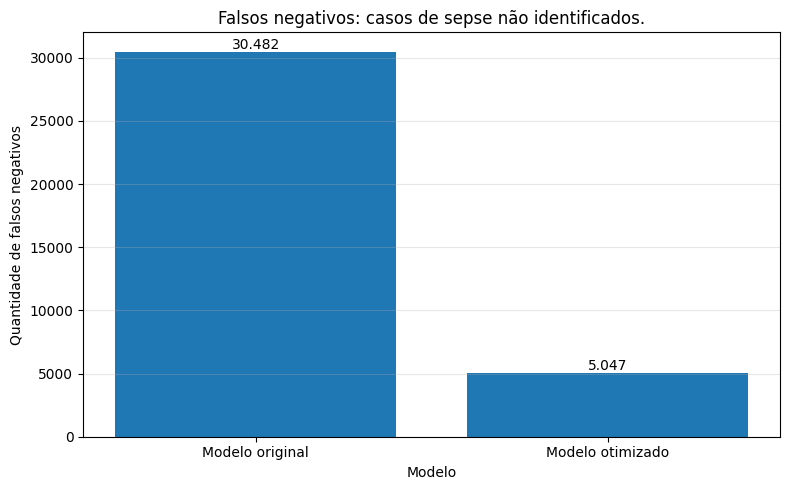

In [15]:
plot_bar_comparison(
    comparison_view,
    "modelo",
    "false_negatives",
    "Falsos negativos: casos de sepse não identificados.",
    "Modelo",
    "Quantidade de falsos negativos",
    format_large_number,
)

Falsos positivos representam alertas emitidos para casos sem sepse real. O aumento desses alertas é o principal custo do ganho de sensibilidade do modelo otimizado.

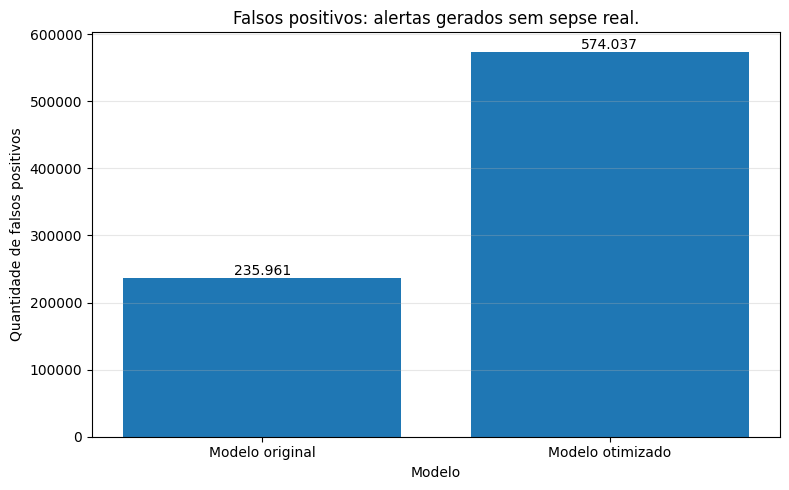

In [16]:
plot_bar_comparison(
    comparison_view,
    "modelo",
    "false_positives",
    "Falsos positivos: alertas gerados sem sepse real.",
    "Modelo",
    "Quantidade de falsos positivos",
    format_large_number,
)

A precision mostra a proporção de alertas positivos que realmente correspondem a casos positivos. Como o modelo otimizado gerou mais alertas, a precision foi reduzida.

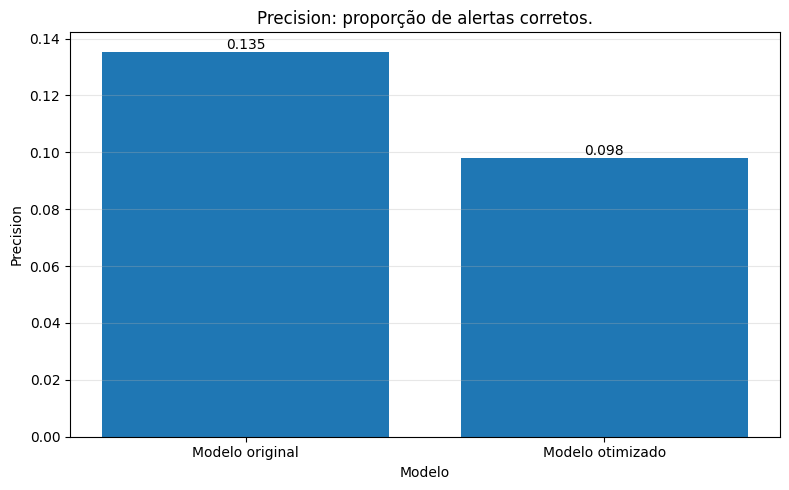

In [17]:
plot_bar_comparison(
    comparison_view,
    "modelo",
    "precision",
    "Precision: proporção de alertas corretos.",
    "Modelo",
    "Precision",
    format_percent,
)

O F1-score combina recall e precision em uma única métrica. No modelo otimizado, o recall aumentou bastante, mas a precision caiu devido ao crescimento dos falsos positivos.

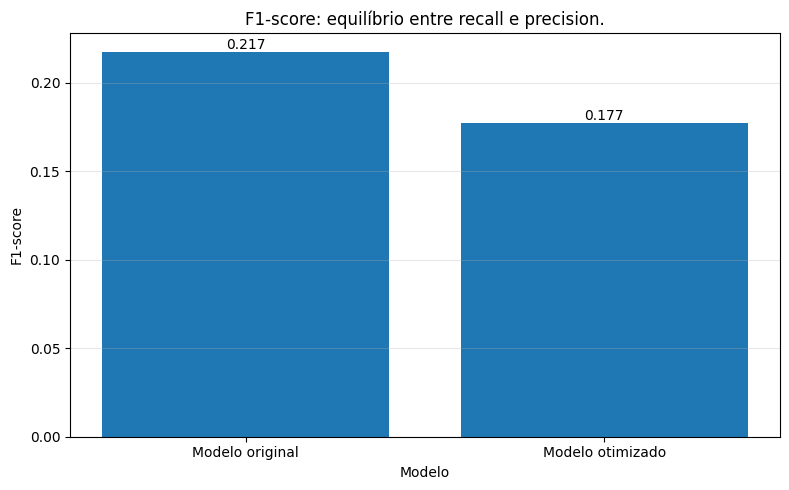

In [18]:
plot_bar_comparison(
    comparison_view,
    "modelo",
    "f1_score",
    "F1-score: equilíbrio entre recall e precision.",
    "Modelo",
    "F1-score",
    format_percent,
)

Os gráficos mostram que o modelo otimizado ficou mais sensível. Ele reduziu os falsos negativos, ou seja, deixou passar menos casos reais de sepse. Porém, essa maior sensibilidade aumentou os falsos positivos, gerando mais alertas em pacientes sem sepse. Esse resultado representa um trade-off esperado em modelos de triagem médica.

## 11. Explicação com LLM.

A camada de LLM ou fallback local melhora a interpretabilidade do resultado. Ela não realiza diagnóstico e não substitui avaliação médica; apenas traduz a saída do modelo para uma explicação mais compreensível.

O prompt orienta o sistema a usar apenas os dados fornecidos, não inventar informações e reforçar que o modelo é um apoio acadêmico. Quando não há `OPENAI_API_KEY`, o fallback local gera uma explicação segura baseada em template.

In [19]:
examples = llm_examples.get("examples", {})
positive_example = examples.get("positive_example")
negative_example = examples.get("negative_example")

if positive_example:
    display(Markdown("### Exemplo positivo"))
    display(pd.DataFrame([{
        "modo": positive_example.get("mode"),
        "probability": positive_example.get("probability"),
        "predicted_class": positive_example.get("predicted_class"),
        "explanation": positive_example.get("explanation"),
    }]))

if negative_example:
    display(Markdown("### Exemplo negativo"))
    display(pd.DataFrame([{
        "modo": negative_example.get("mode"),
        "probability": negative_example.get("probability"),
        "predicted_class": negative_example.get("predicted_class"),
        "explanation": negative_example.get("explanation"),
    }]))

if predict_example:
    display(Markdown("### Exemplo integrado de predicao com explicacao"))
    display(pd.DataFrame([{
        "probability": predict_example.get("probability"),
        "threshold": predict_example.get("threshold"),
        "predicted_class": predict_example.get("predicted_class"),
        "predicted_label": predict_example.get("predicted_label"),
        "explanation_mode": predict_example.get("explanation_mode"),
        "explanation": predict_example.get("explanation"),
    }]))
    display(Markdown("**Variáveis clínicas usadas no exemplo:**"))
    display(pd.DataFrame([predict_example.get("clinical_variables", {})]))
    display(Markdown("**Fatores destacados:**"))
    display(pd.DataFrame({"Fatores": predict_example.get("influencing_factors", [])}))

### Exemplo positivo

,modo,probability,predicted_class,explanation
0,template_fallback,0.72,1,O modelo preditivo estimou probabilidade de se...


### Exemplo negativo

,modo,probability,predicted_class,explanation
0,template_fallback,0.07,0,O modelo preditivo estimou probabilidade de se...


### Exemplo integrado de predicao com explicacao

,probability,threshold,predicted_class,predicted_label,explanation_mode,explanation
0,0.615197,0.15,1,sepse,template_fallback,O modelo preditivo estimou probabilidade de se...


**Variáveis clínicas usadas no exemplo:**

,MAP,Lactate,Resp,Temp,WBC,HR
0,58.0,3.1,28.0,38.4,16.0,112.0


**Fatores destacados:**

,Fatores
0,pressao arterial media baixa
1,lactato elevado
2,frequencia respiratoria aumentada
3,temperatura alterada
4,leucocitos alterados
5,frequencia cardiaca elevada


## 12. Limitações.

- Base de dados desbalanceada.
- Aumento expressivo de falsos positivos.
- Redução de precision e F1-score.
- Projeto acadêmico, sem validação clínica prospectiva.
- A LLM não realiza diagnóstico.
- O uso real exigiria governança clínica, validação externa e monitoramento contínuo.

## 13. Conclusão.

O Algoritmo Genético encontrou uma configuração de hiperparâmetros que aumentou o recall e reduziu os falsos negativos em relação ao modelo original. O principal custo foi o aumento dos falsos positivos, evidenciando um trade-off entre sensibilidade e precisão. A integração com LLM ou fallback local contribui para tornar a saída do modelo mais compreensível, mantendo a ressalva de que o sistema é acadêmico e não substitui avaliação médica.

## 14. Checklist final.

- Baseline carregado.
- Três experimentos do Algoritmo Genético analisados.
- Melhor experimento identificado.
- Threshold ajustado em validação.
- Modelo otimizado comparado ao modelo original.
- Explicação com LLM ou fallback local demonstrada.
- Limitações documentadas.